In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import json
import shap


Total de jogos: 570
Vitórias do time 1 (team_1): 295
Vitórias do time 2 (team_2): 275
Percentual de vitórias do lado azul: 51.75%


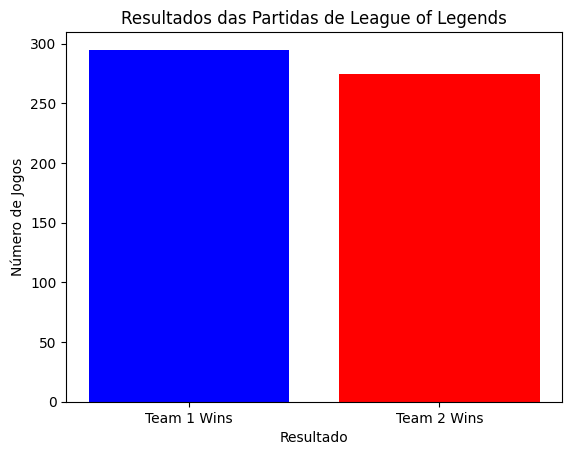

In [3]:
file_path = '../../repository/lcs/LCS_matches_4.csv'

# Carregar os dados organizados
df = pd.read_csv(file_path)

# Total de jogos
total_matches = df.shape[0]

# Contagem de vitórias
team_1_wins = (df['winner'] == df['team_1']).sum()
team_2_wins = (df['winner'] == df['team_2']).sum()


# Lista de valores para os times e seus resultados
win_counts = [team_1_wins, team_2_wins]

# Cálculo da porcentagem de vitórias do time 1
team_1_win_rate = (team_1_wins / total_matches) * 100

# Exibir estatísticas
print("Total de jogos:", total_matches)
print("Vitórias do time 1 (team_1):", team_1_wins)
print("Vitórias do time 2 (team_2):", team_2_wins)
print(f"Percentual de vitórias do lado azul: {team_1_win_rate:.2f}%")

# Criar gráfico de barras
x = ['Team 1 Wins', 'Team 2 Wins']
y = win_counts

plt.bar(x, y, color=['blue', 'red'])
plt.xlabel('Resultado')
plt.ylabel('Número de Jogos')
plt.title('Resultados das Partidas de League of Legends')
plt.show()

In [4]:
matches_df = pd.read_csv(file_path)
# Ordenar os dados pelas datas dos jogos para manter a ordem cronológica
# Pois temos informação temporal.
matches_df = matches_df.sort_values(by='date')
print(matches_df.head())

                 match_id       team_1            team_2 league  \
0   ESPORTSTMNT01_2691713          TSM       100 Thieves    LCS   
13  ESPORTSTMNT01_2701892       Cloud9  Golden Guardians    LCS   
14  ESPORTSTMNT01_2701898     FlyQuest               TSM    LCS   
15  ESPORTSTMNT01_2701905  100 Thieves  Golden Guardians    LCS   
16  ESPORTSTMNT01_2701917       Cloud9          FlyQuest    LCS   

                   date       winner  gamelength   firsttower_team  \
0   2022-01-14 21:26:31  100 Thieves        1595       100 Thieves   
13  2022-01-14 23:05:35       Cloud9        2079  Golden Guardians   
14  2022-01-15 00:00:36          TSM        3007          FlyQuest   
15  2022-01-15 01:14:39  100 Thieves        1976       100 Thieves   
16  2022-01-15 02:13:10       Cloud9        2149            Cloud9   

     firstblood_team  firstdragon_team  
0                TSM       100 Thieves  
13            Cloud9            Cloud9  
14               TSM          FlyQuest  
15  Golden G

In [5]:
# Verificar se há valores nulos em todo o DataFrame
print("Contagem de valores nulos em cada coluna:")
print(matches_df.isna().sum())

# Verificar se há linhas com valores nulos e exibir essas linhas
linhas_com_na = matches_df[matches_df.isna().any(axis=1)]
if not linhas_com_na.empty:
    print("\nLinhas com valores nulos:")
    print(linhas_com_na)
else:
    print("\nNenhuma linha com valores nulos encontrada.")

# Exibir as colunas específicas que têm valores ausentes
colunas_com_na = matches_df.columns[matches_df.isna().any()]
print("\nColunas com valores ausentes:", colunas_com_na.tolist())

# Remover linhas com valores nulos em qualquer coluna e atualizar o DataFrame
matches_df = matches_df.dropna()

print("\nDataFrame atualizado sem valores nulos")

Contagem de valores nulos em cada coluna:
match_id            0
team_1              0
team_2              0
league              0
date                0
winner              0
gamelength          0
firsttower_team     0
firstblood_team     0
firstdragon_team    0
dtype: int64

Nenhuma linha com valores nulos encontrada.

Colunas com valores ausentes: []

DataFrame atualizado sem valores nulos


In [6]:
# Encode team names and league
le_team = LabelEncoder()
le_league = LabelEncoder()

matches_df['game_id'] = matches_df.index
matches_df['team_1_encoded'] = le_team.fit_transform(matches_df['team_1'])
matches_df['team_2_encoded'] = le_team.fit_transform(matches_df['team_2'])
matches_df['league_encoded'] = le_league.fit_transform(matches_df['league'])
matches_df['result_encoded'] = (matches_df['winner'] == matches_df['team_1']).astype(int)
matches_df['firsttower_team_encoded'] = le_team.fit_transform(matches_df['firsttower_team'])
matches_df['firstblood_team_encoded'] = le_team.fit_transform(matches_df['firstblood_team'])
matches_df['firstdragon_team_encoded'] = le_team.fit_transform(matches_df['firstdragon_team'])



# Variáveis que serão usadas para treinar o modelo
# Features: (team names 1: team names 2 : league: tempo de jogo)
X = matches_df[['team_1_encoded', 'team_2_encoded', 'league_encoded', 'gamelength', 'firsttower_team_encoded', 'firstblood_team_encoded', 'firstdragon_team_encoded']]

# Target: vencedor (codificado como 0 ou 1 com base em se o time_1 é o vencedor)
y = matches_df['result_encoded']

display(matches_df.head())

,match_id,team_1,team_2,league,date,winner,gamelength,firsttower_team,firstblood_team,firstdragon_team,game_id,team_1_encoded,team_2_encoded,league_encoded,result_encoded,firsttower_team_encoded,firstblood_team_encoded,firstdragon_team_encoded
0,ESPORTSTMNT01_2691713,TSM,100 Thieves,LCS,2022-01-14 21:26:31,100 Thieves,1595,100 Thieves,TSM,100 Thieves,0,9,0,0,0,0,9,0
13,ESPORTSTMNT01_2701892,Cloud9,Golden Guardians,LCS,2022-01-14 23:05:35,Cloud9,2079,Golden Guardians,Cloud9,Cloud9,13,1,6,0,1,6,1,1
14,ESPORTSTMNT01_2701898,FlyQuest,TSM,LCS,2022-01-15 00:00:36,TSM,3007,FlyQuest,TSM,FlyQuest,14,5,9,0,0,5,9,5
15,ESPORTSTMNT01_2701905,100 Thieves,Golden Guardians,LCS,2022-01-15 01:14:39,100 Thieves,1976,100 Thieves,Golden Guardians,Golden Guardians,15,0,6,0,1,0,6,6
16,ESPORTSTMNT01_2701917,Cloud9,FlyQuest,LCS,2022-01-15 02:13:10,Cloud9,2149,Cloud9,FlyQuest,Cloud9,16,1,5,0,1,1,5,1


In [7]:
# Normalização dos dados de entrada (features)
scaler = MinMaxScaler().fit(X)
X_scaled = scaler.transform(X)
print('Features: ', X_scaled.shape)
print(X_scaled)

Features:  (570, 7)
[[0.9 0.  0.  ... 0.  0.9 0. ]
 [0.1 0.6 0.  ... 0.6 0.1 0.1]
 [0.5 0.9 0.  ... 0.5 0.9 0.5]
 ...
 [0.8 0.1 0.  ... 0.8 0.8 0.8]
 [0.1 0.8 0.  ... 0.8 0.8 0.8]
 [0.1 0.8 0.  ... 0.1 0.8 0.8]]


In [8]:
# Definir percentuais de treino, teste e previsão
# Treino      representa 80% dos dados
# Teste       representa 10% dos dados
# Previsão    representa 10% dos dados
train_ratio = 0.8
test_ratio = 0.1

# Calcular os índices para separação
total_matches = matches_df.shape[0]

train_size = int(train_ratio * total_matches)
test_size = int(test_ratio * total_matches)

# Separação manual dos dados
X_train = X_scaled[:train_size]
y_train = y[:train_size]

X_test = X_scaled[train_size:train_size + test_size]
y_test = y[train_size:train_size + test_size]

X_prediction = X_scaled[train_size + test_size:]

print(len(X_train), len(y_train))
print(len(X_test), len(y_test))


456 456
57 57


Using 456 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Acurácia do modelo de Naive Bayes: 49.12%
F1 Score: 49.12%%


  0%|          | 0/57 [00:00<?, ?it/s]

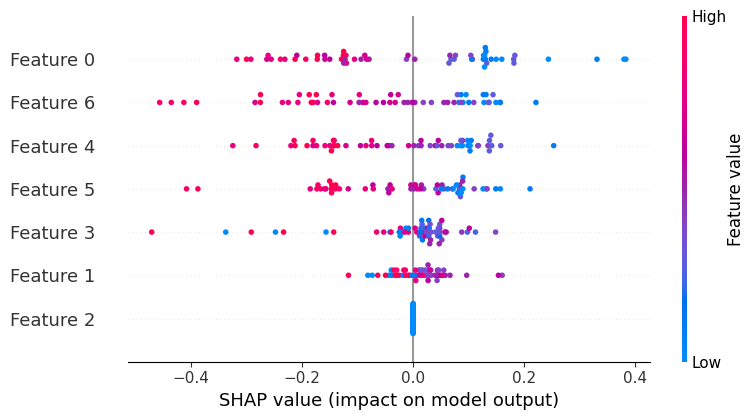

In [16]:
# Criar o modelo Naive Bayes
model = GaussianNB()

# Treinar o modelo
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average = 'micro')

print(f'Acurácia do modelo de Naive Bayes: {accuracy * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')

# Valores positivos de SHAP indicam um recurso que está elevando a previsão do modelo, enquanto valores negativos sugerem que o recurso está elevando a previsão para baixo.
explainer_model = shap.KernelExplainer(model.predict, X_train)
shap_values = explainer_model.shap_values(X_test)

# Criar o gráfico de resumo dos valores SHAP
shap.summary_plot(shap_values, X_test)

Using 456 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Acurácia do modelo de Regressão Logística: 57.89%
F1 Score: 57.89%%


  0%|          | 0/57 [00:00<?, ?it/s]

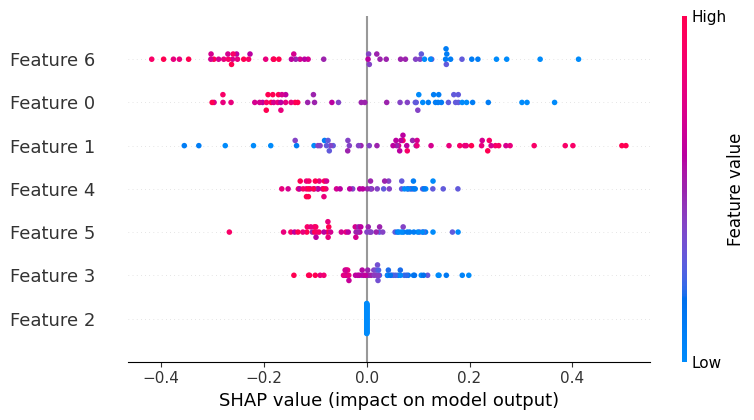

In [17]:
# Criar o modelo de Regressão Logística
logistic_model = LogisticRegression()

# Treinar o modelo
logistic_model.fit(X_train, y_train)

# Fazer previsões
y_pred_logistic = logistic_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic, average = 'micro')

print(f'Acurácia do modelo de Regressão Logística: {accuracy_logistic * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')


# Valores positivos de SHAP indicam um recurso que está elevando a previsão do modelo, enquanto valores negativos sugerem que o recurso está elevando a previsão para baixo.
explainer_model = shap.KernelExplainer(logistic_model.predict, X_train)
shap_values = explainer_model.shap_values(X_test)

# Criar o gráfico de resumo dos valores SHAP
shap.summary_plot(shap_values, X_test)

Using 456 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Acurácia do modelo SVM: 64.91%
F1 Score: 64.91%%


  0%|          | 0/57 [00:00<?, ?it/s]

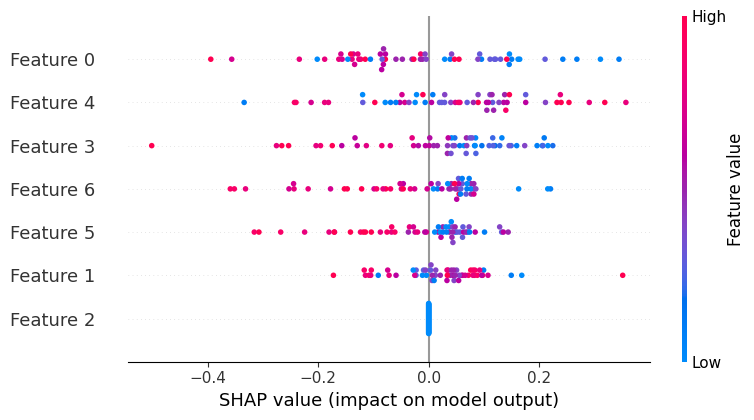

In [23]:
# Criar o modelo SVM
svm_model = SVC()
svm_model = SVC(probability=True)

# Treinar o modelo SVM
svm_model.fit(X_train, y_train)

# Fazer previsões com o modelo SVM
y_pred_svm = svm_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm, average = 'micro')


print(f'Acurácia do modelo SVM: {accuracy_svm * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')

explainer_svm_model = shap.KernelExplainer(svm_model.predict, X_train)
shap_values = explainer_svm_model.shap_values(X_test)

# Plotar o resumo dos valores SHAP
shap.summary_plot(shap_values, X_test)


Acurácia do modelo de Árvore de Decisão: 54.39%
F1 Score: 54.39%%


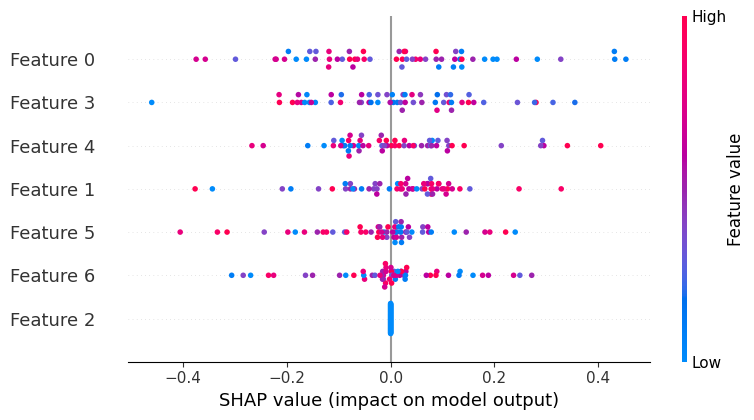

In [19]:
# Criar o modelo de Árvore de Decisão
tree_model = DecisionTreeClassifier()

# Treinar o modelo de Árvore de Decisão
tree_model.fit(X_train, y_train)

# Fazer previsões com o modelo de Árvore de Decisão
y_pred_tree = tree_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_tree = accuracy_score(y_test, y_pred_tree)
f1 = f1_score(y_test, y_pred_tree, average = 'micro')


print(f'Acurácia do modelo de Árvore de Decisão: {accuracy_tree * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')


explainer_tree_model = shap.TreeExplainer(tree_model)
shap_values = explainer_tree_model.shap_values(X_test)

shap.summary_plot(shap_values[:,:,1], X_test)

In [20]:
results = {"LCS4": {"Naive Bayes": accuracy, "Regressao Logistica": accuracy_logistic, "SVM": accuracy_svm, "Arvore de Decisao": accuracy_tree}}
with open("LCS4_results.json", "w") as f:
    json.dump(results, f)

In [21]:
# Executando a previsão pelo método de maior acurácia (Naive Bayes)
prevision = X_prediction
game_id = matches_df['game_id']
game_id_prev = game_id[train_size + test_size:]

result = matches_df['result_encoded']
result_prev = result[train_size + test_size:]

pred = model.predict(prevision)



df = pd.DataFrame({'Resultado': result_prev, 'Previsão': pred, 'Game_id': game_id_prev})
print(df[:10])


     Resultado  Previsão  Game_id
521          1         0      521
524          1         0      524
530          1         1      530
531          0         1      531
525          1         0      525
522          1         1      522
532          1         1      532
533          0         1      533
189          0         0      189
192          0         0      192


<Axes: xlabel='Previsão', ylabel='Resultado'>

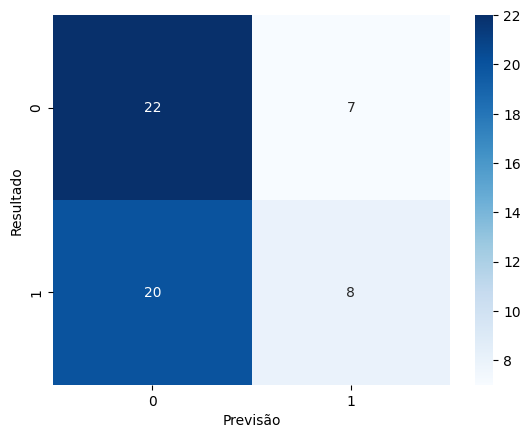

In [22]:
#Matrix de confusão
df = pd.DataFrame(df,columns = ['Resultado','Previsão'])

cf_matrix = pd.crosstab(df['Resultado'], df['Previsão'], rownames = ['Resultado'] , colnames = ['Previsão'])

sns.heatmap(cf_matrix, annot = True, cmap = 'Blues', fmt = 'g')